In [ ]:
from google.colab import files
import os

# 1. Upload the kaggle.json file
if not os.path.exists("/root/.kaggle/kaggle.json"):
    uploaded = files.upload()

    # 2. Move it to the hidden .kaggle folder
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!pip install optuna xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 30.4 MB/s eta 0:00:00


In [ ]:
!kaggle datasets download -d mmoreaux/environmental-sound-classification-50

Dataset URL: https://www.kaggle.com/datasets/mmoreaux/environmental-sound-classification-50
License(s): CC-BY-NC-SA-4.0
 92% 1.31G/1.42G [00:08<00:03, 40.3MB/s]
100% 1.42G/1.42G [00:08<00:00, 180MB/s] 


In [ ]:
!unzip -q environmental-sound-classification-50.zip -d ./data

In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, LabelEncoder, PowerTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score,GroupKFold
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, PrecisionRecallDisplay
import warnings
warnings.filterwarnings("ignore")
from xgboost import XGBClassifier
from collections import Counter
import optuna

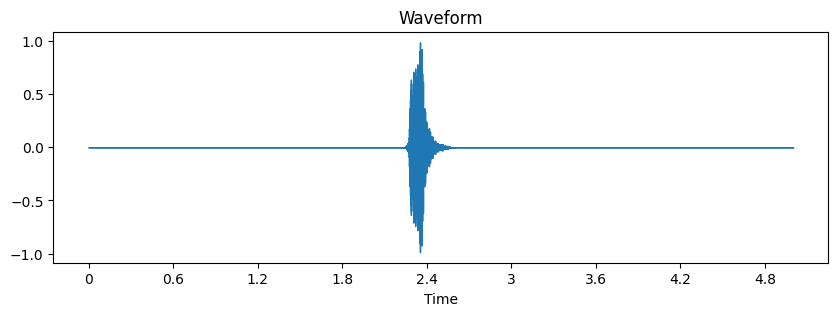

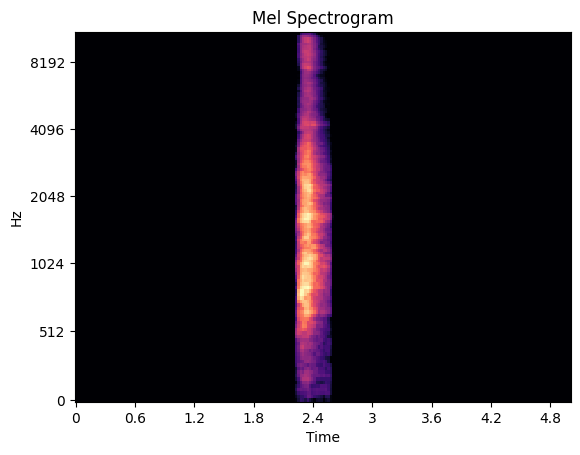

In [ ]:
y, sr = librosa.load("data/audio/audio/1-100032-A-0.wav", sr= 22050)

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.show()

S = librosa.feature.melspectrogram(y=y, sr=sr)
librosa.display.specshow(librosa.power_to_db(S), sr=sr, x_axis='time', y_axis='mel')
plt.title("Mel Spectrogram")
plt.show()


In [ ]:
y.shape

(110250,)

In [ ]:
def extract_features(path):
    y, sr = librosa.load(path, sr=None)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)

    zcr = librosa.feature.zero_crossing_rate(y)
    rms = librosa.feature.rms(y=y)

    chroma = librosa.feature.chroma_stft(y=y, sr=sr)

    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    tempo = float(tempo)  # Ensure scalar

    features = np.concatenate([
        mfcc.mean(axis=1), mfcc.std(axis=1),
        centroid.mean(axis=1), centroid.std(axis=1),
        bandwidth.mean(axis=1), bandwidth.std(axis=1),
        rolloff.mean(axis=1), rolloff.std(axis=1),
        zcr.mean(axis=1), zcr.std(axis=1),
        rms.mean(axis=1), rms.std(axis=1),
        chroma.mean(axis=1),
        np.array([tempo])
    ])

    return features

In [ ]:
def segment_audio(y, sr, segment_length=1.0, hop_length=0.5):
    seg_len = int(segment_length * sr)
    hop = int(hop_length * sr)

    segments = []
    for start in range(0, len(y) - seg_len + 1, hop):
        segments.append(y[start:start + seg_len])
    return segments

def extract_features_from_segment(y_seg, sr = 22050):
    mfcc = librosa.feature.mfcc(y=y_seg, sr=sr, n_mfcc=20)
    chroma = librosa.feature.chroma_stft(y=y_seg, sr=sr)
    centroid = librosa.feature.spectral_centroid(y=y_seg, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y_seg)
    rms = librosa.feature.rms(y=y_seg)

    def stats(x):
        return np.concatenate([x.mean(axis=1), x.std(axis=1)])

    return np.concatenate([
        stats(mfcc),
        stats(chroma),
        centroid.mean(axis=1),
        zcr.mean(axis=1),
        rms.mean(axis=1)
    ])


In [ ]:
meta = pd.read_csv("/content/data/esc50.csv")
X, y_labels, file_ids = [], [], []

for idx, row in meta.iterrows():
    path = os.path.join("/content/data/audio/audio/", row.filename)
    y_audio, sr = librosa.load(path, sr=None)

    segments = segment_audio(y_audio, sr)

    for seg in segments:
        feats = extract_features_from_segment(seg, sr)
        X.append(feats)
        y_labels.append(row.category)
        file_ids.append(row.filename)

In [ ]:
df = pd.DataFrame(X)
df["label"] = y_labels
df["file_id"] = file_ids

In [ ]:
df.to_csv("esc_segmented.csv",index = False)

In [ ]:
df = pd.DataFrame(pd.read_csv("/content/esc_segmented.csv"))

In [ ]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,59,60,61,62,63,64,65,66,label,file_id
0,-1131.370728,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,dog,1-100032-A-0.wav
1,-1131.370728,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,dog,1-100032-A-0.wav
2,-1131.370728,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,dog,1-100032-A-0.wav
3,-512.783020,33.813206,-29.313803,-16.289793,-14.023194,1.003574,-9.486242,-1.228666,1.660045,0.826270,...,0.216578,0.378307,0.318653,0.157291,0.188594,913.791047,0.023684,0.036890,dog,1-100032-A-0.wav
4,-502.828583,41.249733,-33.226501,-21.113008,-15.222867,1.274489,-9.911440,-1.289544,2.543205,1.668996,...,0.224155,0.421710,0.352799,0.166827,0.210714,1364.852828,0.036301,0.037324,dog,1-100032-A-0.wav


In [ ]:
for i in num_cols:
    plt.figure(figsize=(16, 5))
    sns.kdeplot(df[i])
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].skew()

,0
0,-1.456735
1,-0.210013
2,-0.295866
3,-0.322661
4,-0.344865
...,...
62,-0.547480
63,-0.592844
64,0.970758
65,2.340104


In [ ]:
type(num_cols)

pandas.core.indexes.base.Index

In [ ]:
df.columns

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36',
       '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48',
       '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60',
       '61', '62', '63', '64', '65', '66', 'label', 'file_id'],
      dtype='object')

In [ ]:
# L = [13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,31,32,33,34,35,48]
# L = [str(i) for i in L]
df_c = df.copy()
pt = PowerTransformer(method='yeo-johnson', standardize=True)
for i in num_cols:
  df_c[i] = pt.fit_transform(df_c[[i]])

In [ ]:
df_c[num_cols].skew()

,0
0,-0.639640
1,-0.317471
2,-0.002589
3,0.002901
4,0.013257
...,...
62,-0.009451
63,-0.005395
64,-0.400946
65,0.180101


In [ ]:
df_c.head()

,0,1,2,3,4,5,6,7,8,9,...,59,60,61,62,63,64,65,66,label,file_id
0,-2.415527,-1.762672,0.646143,-0.881519,0.498735,-0.850995,0.456843,-0.680477,0.403047,-0.575292,...,-1.913230,-1.936106,-1.932223,-1.938212,-1.927158,-2.287363,-1.618898,-1.247760,dog,1-100032-A-0.wav
1,-2.415527,-1.762672,0.646143,-0.881519,0.498735,-0.850995,0.456843,-0.680477,0.403047,-0.575292,...,-1.913230,-1.936106,-1.932223,-1.938212,-1.927158,-2.287363,-1.618898,-1.247760,dog,1-100032-A-0.wav
2,-2.415527,-1.762672,0.646143,-0.881519,0.498735,-0.850995,0.456843,-0.680477,0.403047,-0.575292,...,-1.913230,-1.936106,-1.932223,-1.938212,-1.927158,-2.287363,-1.618898,-1.247760,dog,1-100032-A-0.wav
3,-0.536020,-1.224160,-0.079279,-1.406836,-0.170006,-0.795188,-0.156587,-0.769533,0.538644,-0.498847,...,0.056822,2.229180,1.337797,-0.563731,-0.252832,-0.986709,-0.851094,-0.243540,dog,1-100032-A-0.wav
4,-0.501695,-1.109710,-0.173049,-1.556715,-0.225069,-0.779916,-0.183353,-0.773919,0.611554,-0.420820,...,0.143113,2.923257,1.831852,-0.464201,-0.004950,-0.665318,-0.509205,-0.233904,dog,1-100032-A-0.wav


In [ ]:
# X = df_c.drop(["label","file_id"], axis=1)
# y = df_c["label"]
# #X = StandardScaler().fit_transform(X)
# Y = LabelEncoder().fit_transform(y)
# X_train_full, X_test, y_train_full, y_test = train_test_split(
#     X, Y, test_size=0.2, stratify=y, random_state=42
# )

# X_train, X_val, y_train, y_val = train_test_split(
#     X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
# )

In [ ]:
X_all = df_c.drop(["label","file_id"], axis=1).values
le = LabelEncoder()
y_all = le.fit_transform(df_c["label"])
groups = df_c["file_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))

X_train_full, X_test = X_all[train_idx], X_all[test_idx]
y_train_full, y_test = y_all[train_idx], y_all[test_idx]
groups_train = groups[train_idx]

# Now split train into train/val, again by group
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx2, val_idx2 = next(gss2.split(X_train_full, y_train_full, groups=groups_train))

X_train, X_val = X_train_full[train_idx2], X_train_full[val_idx2]
y_train, y_val = y_train_full[train_idx2], y_train_full[val_idx2]

In [ ]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1500),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 1, 10),
        "objective": "multi:softprob",
        "num_class": 50,
        "eval_metric": "mlogloss",
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBClassifier(**params)

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)

    return acc

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

[I 2026-01-06 06:27:53,357] A new study created in memory with name: no-name-7ff5261c-d873-44c3-a0aa-5505d203e379
[W 2026-01-06 06:27:59,977] Trial 0 failed with parameters: {'n_estimators': 1265, 'max_depth': 4, 'learning_rate': 0.08472766741299474, 'subsample': 0.938108829337434, 'colsample_bytree': 0.6734092301165775, 'min_child_weight': 5, 'gamma': 0.14327449797423675, 'reg_alpha': 6.688136942083726, 'reg_lambda': 8.617454873394195} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipython-input-810245332.py", line 21, in objective
    model.fit(
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 774, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py", line 1806, in fi

KeyboardInterrupt: 

In [ ]:
[I 2026-01-05 16:59:42,888] Trial 23 finished with value: 0.8 and parameters: {'n_estimators': 1012, 'max_depth': 9, 'learning_rate': 0.08400652066887725, 'subsample': 0.8964817523184703, 'colsample_bytree': 0.6392086212394985, 'min_child_weight': 2, 'gamma': 0.017872718039370135, 'reg_alpha': 0.22118357835464297, 'reg_lambda': 7.039782104590273}. Best is trial 23 with value: 0.8.

In [ ]:
# "objective": "multi:softprob",
#         "num_class": 50,
#         "eval_metric": "mlogloss",
#         "random_state": 42,
#         "n_jobs": -1

In [ ]:
model = XGBClassifier(n_estimators = 1012, max_depth = 9, learning_rate = 0.08400652066887725, subsample = 0.8964817523184703, colsample_bytree = 0.6392086212394985, min_child_weight = 2, gamma = 0.017872718039370135, reg_alpha = 0.22118357835464297, reg_lambda = 7.039782104590273 , objective = "multi:softprob", num_class = 50, eval_metric = "mlogloss", random_state = 42, n_jobs = -1)
model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6392086212394985, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mlogloss', feature_types=None, feature_weights=None,
              gamma=0.017872718039370135, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.08400652066887725, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1012, n_jobs=-1, num_class=50, ...)

In [ ]:
pred = model.predict(X_val)
print(classification_report(y_val, pred))
print(accuracy_score(y_val,pred))

preds_proba = model.predict_proba(X_val)
top3 = np.argsort(preds_proba, axis=1)[:, -3:]
top3_acc = np.mean([y_val[i] in top3[i] for i in range(len(y_val))])
print("Top-3 Accuracy:", top3_acc)

              precision    recall  f1-score   support

           0       0.81      0.61      0.70        72
           1       0.32      0.19      0.24        36
           2       0.71      0.87      0.79        63
           3       0.36      0.32      0.34        63
           4       0.34      0.50      0.40        36
           5       0.12      0.11      0.11        27
           6       0.51      0.81      0.63        54
           7       0.52      0.87      0.65        54
           8       0.64      0.80      0.71        45
           9       0.71      0.67      0.69        54
          10       0.90      0.73      0.81        63
          11       0.56      0.22      0.32        81
          12       0.24      0.19      0.21        54
          13       0.19      0.25      0.21        36
          14       0.64      0.78      0.70        72
          15       0.89      0.65      0.75        63
          16       0.79      0.69      0.73        54
          17       0.81    

In [ ]:
model.predict(X_val)

array([ 9,  9,  9, ..., 29, 29, 39])

In [ ]:
L = [120,130,14,45,456,678,345,234,367]

In [ ]:
for i in L:
  print(le.inverse_transform(model.predict(X_val[i].reshape(1, -1))), le.inverse_transform(y_val[i].reshape(1,-1)))

['glass_breaking'] ['coughing']
['glass_breaking'] ['insects']
['chainsaw'] ['chainsaw']
['coughing'] ['water_drops']
['chainsaw'] ['chainsaw']
['cow'] ['engine']
['frog'] ['sheep']
['car_horn'] ['wind']
['wind'] ['wind']


In [ ]:
Counter(y_train)

Counter({np.int64(18): 234,
         np.int64(7): 252,
         np.int64(46): 198,
         np.int64(43): 270,
         np.int64(20): 279,
         np.int64(3): 225,
         np.int64(16): 252,
         np.int64(9): 207,
         np.int64(23): 324,
         np.int64(0): 216,
         np.int64(33): 234,
         np.int64(35): 243,
         np.int64(45): 207,
         np.int64(48): 189,
         np.int64(10): 225,
         np.int64(49): 225,
         np.int64(24): 225,
         np.int64(25): 207,
         np.int64(2): 234,
         np.int64(4): 297,
         np.int64(14): 207,
         np.int64(28): 216,
         np.int64(21): 234,
         np.int64(36): 297,
         np.int64(30): 252,
         np.int64(29): 189,
         np.int64(22): 216,
         np.int64(12): 216,
         np.int64(39): 216,
         np.int64(6): 270,
         np.int64(13): 207,
         np.int64(42): 216,
         np.int64(44): 207,
         np.int64(34): 225,
         np.int64(17): 225,
         np.int64(8): 243,


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cross_val_score(model,X_val,y_val,cv = skf)

array([0.80729167, 0.81076389, 0.78645833, 0.80034722, 0.81597222])

In [ ]:
groups = df_c["file_id"].values
gkf = GroupKFold(n_splits=5)
scores = cross_val_score(model, X_all, y_all, groups=groups, cv=gkf, scoring="accuracy")
print(scores)
print("Mean:", scores.mean())

[0.55916667 0.51777778 0.56194444 0.56194444 0.5575    ]
Mean: 0.5516666666666666
